<a href="https://colab.research.google.com/github/beyzadurdu6619/ML/blob/main/OneHotEncoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
#One Hot Encoding

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


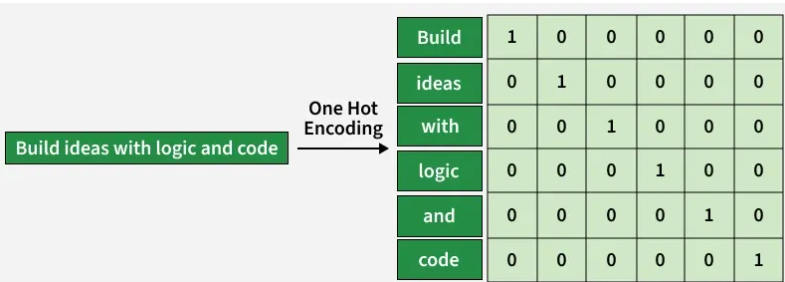

In [76]:
df=pd.read_csv("churn.csv")

In [77]:
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [78]:
df=df.drop(columns=["RowNumber","CustomerId","Surname"])

In [79]:
df.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [80]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [62]:
df.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False


In [81]:
y=df["Exited"]
x=df.drop(columns=["Exited"],axis=1)

In [82]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [83]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf.score(x_test,y_test)


0.8605

In [84]:
df=pd.DataFrame()
df["Takim"]=["BFK","FB","GS","TS","GB","DF","DF","DF","OF","HE","YB"]


In [85]:
pd.get_dummies(df,columns=["Takim"])

,Takim_BFK,Takim_DF,Takim_FB,Takim_GB,Takim_GS,Takim_HE,Takim_OF,Takim_TS,Takim_YB
0,True,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False
4,False,False,False,True,False,False,False,False,False
5,False,True,False,False,False,False,False,False,False
6,False,True,False,False,False,False,False,False,False
7,False,True,False,False,False,False,False,False,False
8,False,False,False,False,False,False,True,False,False
9,False,False,False,False,False,True,False,False,False


In [86]:
ohe=OneHotEncoder()
takim=ohe.fit_transform(df[["Takim"]])


In [87]:
takim.toarray()

array([[1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [88]:
ohe.transform([["FB"]]).toarray()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [90]:
df=pd.read_csv("churn.csv")
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
df.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
#get_dummy yerine one hot encoder yapıyoruz.

In [92]:
ohe=OneHotEncoder()
xd=ohe.fit_transform(df[["Geography","Gender"]]).toarray()

In [93]:
xd

array([[1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       ...,
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0.]])

In [94]:
ohe.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain',
       'Gender_Female', 'Gender_Male'], dtype=object)

In [96]:
xd=pd.DataFrame(xd)

In [97]:
xd.columns=ohe.get_feature_names_out()

In [98]:
xd

,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...
9995,1.0,0.0,0.0,0.0,1.0
9996,1.0,0.0,0.0,0.0,1.0
9997,1.0,0.0,0.0,1.0,0.0
9998,0.0,1.0,0.0,0.0,1.0
